# 05 — Support Vector Machine (SVM)

## Theory

An SVM looks for the **maximum-margin hyperplane** — the decision boundary
that separates the two classes while staying as far as possible from the
nearest training points of either class (the **support vectors**, which are
the only points that actually determine the boundary).

For linearly separable data, this is an optimization problem: maximize the
margin $2/\|w\|$ subject to every point being correctly classified. Real
data usually isn't perfectly separable, so SVMs use a **soft margin**,
allowing some points to violate the margin (or even be misclassified) at a
cost, via the **hinge loss**:

$$J(w) = C\sum_{i=1}^N \max\big(0,\ 1 - y_i(w\cdot x_i)\big) + \|w\|^2$$

**The kernel trick:** many datasets aren't linearly separable in their
original feature space. Rather than explicitly transforming features into a
higher-dimensional space (expensive), SVMs use a **kernel function** that
computes what the dot product *would be* in that higher-dimensional space,
without ever materializing it:

- `linear`: $K(x, x') = x \cdot x'$ — a linear boundary in the original space.
- `rbf` (Gaussian): $K(x, x') = \exp(-\gamma\|x - x'\|^2)$ — an implicit
  infinite-dimensional feature space; can learn highly non-linear boundaries.
- `poly`: polynomial feature interactions of a chosen degree.

`gamma` (for `rbf`) controls how far a single training example's influence
reaches: low `gamma` → smooth, far-reaching influence (simpler boundary);
high `gamma` → each point only influences its immediate neighborhood
(highly wiggly boundary, prone to overfitting).

SVMs, like KNN, compare points via distance/dot products, so **feature
scaling matters a lot** here too.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


--- SVM (RBF baseline) ---
              precision    recall  f1-score   support

   good risk       0.76      0.93      0.84       140
    bad risk       0.67      0.33      0.44        60

    accuracy                           0.75       200
   macro avg       0.72      0.63      0.64       200
weighted avg       0.74      0.75      0.72       200

ROC-AUC: 0.758


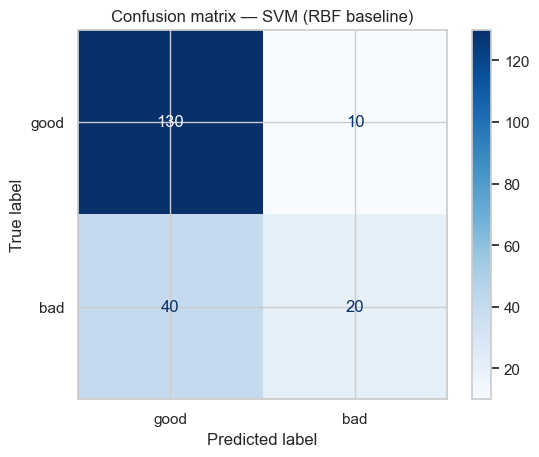

In [4]:
from sklearn.svm import SVC

baseline = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_test_scaled)
y_proba = baseline.predict_proba(X_test_scaled)[:, 1]
evaluate(baseline, X_test_scaled, y_test, y_pred, y_proba, label="SVM (RBF baseline)")


## Regularization — `C` and `gamma`

`C` plays the same conceptual role as it does in Logistic Regression, but
geometrically: it controls how much the model is willing to let points
violate the margin.

- **Small `C`** → the optimizer accepts more margin violations to keep the
  margin wide → simpler boundary → **more regularization** (risk of
  underfitting).
- **Large `C`** → the optimizer heavily penalizes margin violations, pulling
  the boundary tight around the training points → **less regularization**
  (risk of overfitting).

For the `rbf` kernel, `gamma` is a *second* complexity knob, independent of
`C`: high `gamma` lets the boundary wiggle tightly around individual points
(overfitting), low `gamma` forces a smoother, more global boundary.


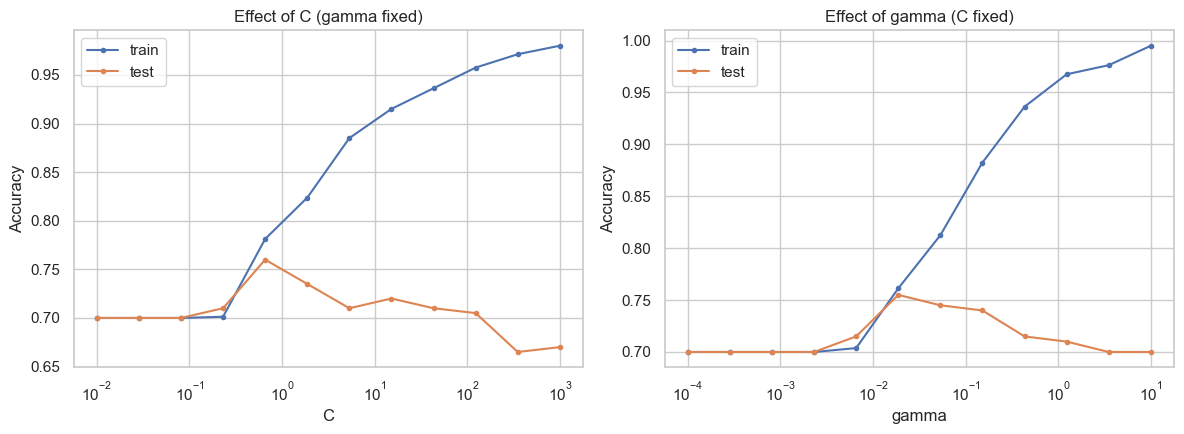

In [5]:
from sklearn.metrics import accuracy_score

Cs = np.logspace(-2, 3, 12)
train_acc, test_acc = [], []
for C in Cs:
    svm = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, svm.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, svm.predict(X_test_scaled)))

gammas = np.logspace(-4, 1, 12)
train_acc_g, test_acc_g = [], []
for g in gammas:
    svm = SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_acc_g.append(accuracy_score(y_train, svm.predict(X_train_scaled)))
    test_acc_g.append(accuracy_score(y_test, svm.predict(X_test_scaled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(Cs, train_acc, marker=".", label="train")
axes[0].plot(Cs, test_acc, marker=".", label="test")
axes[0].set_xscale("log"); axes[0].set_xlabel("C"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Effect of C (gamma fixed)"); axes[0].legend()

axes[1].plot(gammas, train_acc_g, marker=".", label="train")
axes[1].plot(gammas, test_acc_g, marker=".", label="test")
axes[1].set_xscale("log"); axes[1].set_xlabel("gamma"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Effect of gamma (C fixed)"); axes[1].legend()
plt.tight_layout()
plt.show()


## Hyperparameter search

Hyperparameters (`C`, `k`, `max_depth`, ...) are fixed before training, unlike
the weights the fit itself learns. All of them are selected here with **5-fold
cross-validation on the training set only**, scored on ROC-AUC: every
candidate setting is fit on four folds and scored on the fifth, rotating
through all five, and the averaged score decides the winner. The test set
takes no part in the search, which is what keeps the final numbers reported
after it meaningful.

`GridSearchCV` is used where the space is small enough to enumerate
exhaustively and `RandomizedSearchCV` where it is not — sampling a fixed
number of random combinations reaches a near-equivalent setting far more
cheaply once several hyperparameters turn out to barely move the score.


Best params: {'C': np.float64(158.48931924611142), 'gamma': np.float64(0.000630957344480193), 'kernel': 'rbf'}
Best CV ROC-AUC: 0.748
--- SVM (tuned) ---
              precision    recall  f1-score   support

   good risk       0.76      0.91      0.83       140
    bad risk       0.62      0.33      0.43        60

    accuracy                           0.74       200
   macro avg       0.69      0.62      0.63       200
weighted avg       0.72      0.74      0.71       200

ROC-AUC: 0.734


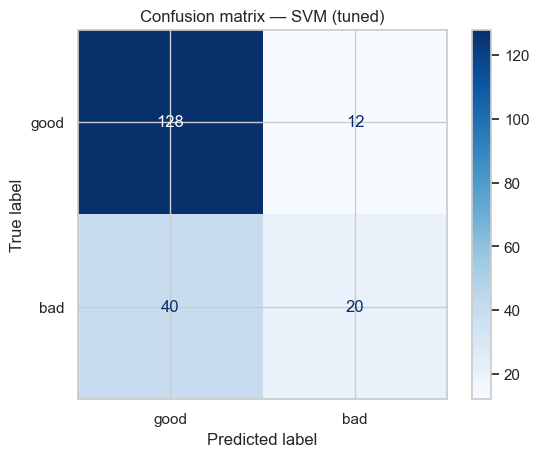

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": np.logspace(-1, 3, 6),
    "gamma": np.logspace(-4, 0, 6),
    "kernel": ["rbf"],
}

grid = GridSearchCV(
    SVC(probability=True, random_state=42), param_grid=param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
y_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
evaluate(best_svm, X_test_scaled, y_test, y_pred, y_proba, label="SVM (tuned)")


## Decision threshold tuning

Every model in this project exposes a predicted probability `P(bad | x)` as
well as a hard label. `.predict()` converts one into the other at a fixed
cutoff of **0.5**: `P(bad) >= 0.5` becomes "bad risk".

0.5 is a library default, not a decision that belongs to this problem, and
two things make it the wrong cutoff here:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so the model
   has to be unusually confident before `P(bad)` clears 0.5. The default
   cutoff quietly favours the majority "good" class and suppresses recall on
   exactly the class a lender needs to catch. (`class_weight="balanced"` is
   the other lever for this and moves roughly the same boundary, but it
   requires retraining.)
2. **Asymmetric costs.** Approving a loan that defaults costs the outstanding
   principal; declining an applicant who would have repaid costs only the
   foregone interest. Those are not the same number, which makes the cutoff a
   business parameter rather than a technicality — and moving it walks the
   model along its existing ROC / precision-recall curve without retraining
   anything.

Two reference cutoffs are computed below:

- **Youden's J** (`J = TPR - FPR`) on the ROC curve — the cutoff that
  separates the classes best when both error types are weighted equally.
- **F1-optimal** on the precision-recall curve — the cutoff that balances
  precision and recall on the positive class, the more informative of the two
  curves under this much imbalance.

> **Methodology caveat — both cutoffs below are selected on the test set,
> which is test-set leakage.**
>
> The scan maximises J / F1 over the held-out data itself, so the test set has
> informed a modelling decision and the two tuned rows are optimistic: they
> are not a clean estimate of how that cutoff would generalise. The step is
> kept because what is being recorded is the *size* of the precision/recall
> shift a cutoff can produce, not the specific threshold value.
>
> This is not how the cutoff would be set in production. There it would be
> chosen on data the model is not being judged on — a separate validation
> fold, or out-of-fold predictions from cross-validation — and then settled in
> deployment: shadow-score live applications for some days or weeks, watch the
> realised default rate against the approval rate, and adjust the cutoff by
> trial and error until it sits where the business wants it. The threshold is
> an operational dial that gets revisited, not a number frozen at training
> time.


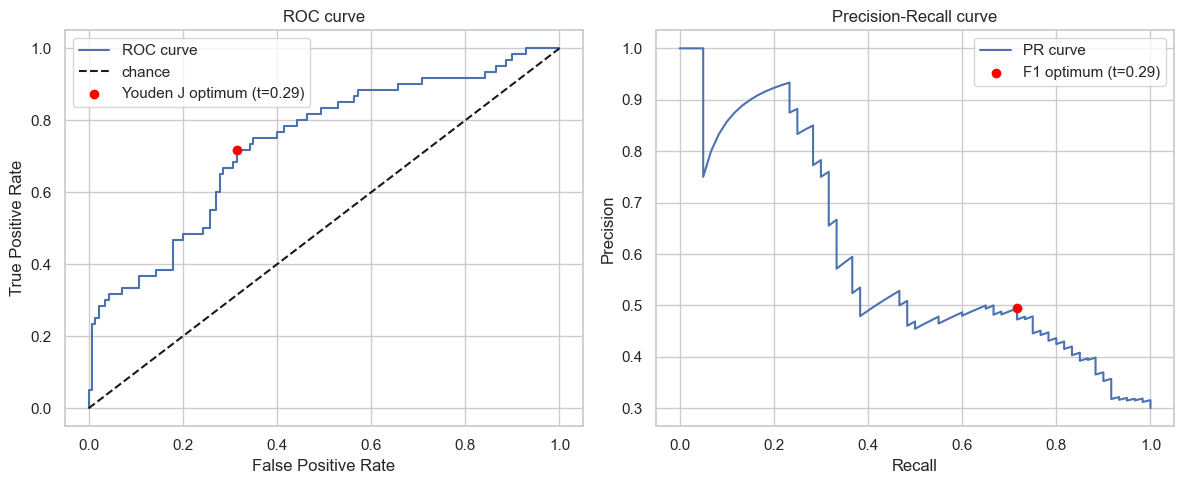

Youden's J optimal threshold: 0.291
F1-optimal threshold:         0.291


,threshold,accuracy,precision,recall,f1
default (0.5),0.50000,0.735,0.606061,0.333333,0.430108
Youden's J,0.29076,0.695,0.494253,0.716667,0.585034
F1-optimal,0.29076,0.695,0.494253,0.716667,0.585034


In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_svm.predict_proba(X_test_scaled)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- The RBF baseline (`C=1.0`, `gamma="scale"`) gave the strongest baseline in
  the project at ROC-AUC **0.758**, a hair ahead of Logistic Regression's
  0.757 — on this data the kernel buys essentially nothing over a linear
  boundary.
- The search settled on a far more extreme corner of the space, `C=158.5` with
  `gamma=6.3e-4`: a hard margin paired with a very wide kernel, which is close
  to a linear model fit tightly. Test ROC-AUC fell to **0.734**, *below* the
  baseline. A 5-fold CV estimate on 800 rows is not precise enough to rank
  settings this close together, and the search ended up fitting the folds.
- `C` and `gamma` interact, so they were searched jointly rather than as two
  independent 1-D sweeps. The winning pair would not have been found by tuning
  either knob on its own.
- Scaling is mandatory for the same reason as in KNN — the kernel is a
  distance.
- At `t = 0.29`, recall on defaulters goes 0.33 -> 0.72. Selected on the test
  set; see the caveat above.
